In [1]:
import pylab as plt
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import copy

from rpy2.robjects.packages import importr
from rpy2.robjects import numpy2ri, pandas2ri, default_converter
from rpy2 import robjects as ro

r2_converter = default_converter + numpy2ri.converter + pandas2ri.converter

import torch
from torch.profiler import profile, ProfilerActivity, record_function

from ereco import model, utils

/home/me/miniconda3/envs/simple-ecal/lib/python3.11/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/me", R: "/home/me/proj/CaloX/CaloCow/simplesim/ecal/notebooks"
  warnings.warn(
/home/me/miniconda3/envs/simple-ecal/lib/python3.11/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib64/R/lib:/usr/lib/jvm/java-23-openjdk/lib/server", R: "/usr/lib64/R/lib:/usr/lib/jvm/java-23-openjdk/lib/server:/usr/lib64/R/lib:/usr/lib/jvm/java-23-openjdk/lib/server"
  warnings.warn(
/home/me/miniconda3/envs/simple-ecal/lib/python3.11/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/tmp/RtmpjtRiMO", R: "/tmp/Rtmpg7X8D8"
  warnings.warn(


We the following notebook explores a few calibration strategy options when relying on an monte-carlo trained NN for energy reconstruction.

A deep NN trained on electron shower events simulated with the Geant4 framework serves as the energy reconstruction method.  The calorimeter consists of 25 PbWO (lead-tungstate) crystals of dimensions 22x22x23 cm^3 arrayed in a 5x5 transverse grid.  This arrangement mimics the CMS barrel ECAL modules.  We simulate primary electron events in which we vary the impact point of the electron across the transverse face of the central crystal.

The training data consists of primary electron energies continuously ranging from 0.5 to 100 GeV.  The NN input consists of the total energy absorbed within each crystal.

At times, we can compare the NN performance, both in calibration and resolution, against a simple energy sum.  We found in all cases, the energy sum performs better than the NN.  The reason behind this go beyond the point of this study, but we can note other studies that found complex ML methods do not have an advantage over energy sums for EM showers.  Hadronic energy reconstruction constitues the primary use of NN reconstruction methods.  Nevertheless, we study EM showers here simply as a basis to study how NNs respond to miscalibrated data, the effects of calibration techniques, and to maintain comparison to intuitive reconstruction methods.

We train the NN on ideal data from the G4 simulation.  We introduce miscalibration effects by random static miscalibration multiplier (miscalibration constant) and random event-wise additive noise for each crystal.

To mimic calibration techniques available to experimenters, we choose a few test primary electron energy test points in which we simulate many events at each primary energy.  We vary the primary energy around the test point mean by some Gaussian distributed error.  This strategy reflects potential test beam data obtained by experimenters.  We further explore the use of distributional regression (location-scale-shape) on miscalibrated data resulting from continuous primary electron energies over the range 0.5 to 100 GeV.  This method allows us to calculate resolution continuously over the range fo the primary particle energy.  We assume perfect measurement of the primary particle energy (the ground truth); therefore this method leads to unusually precise resolution estimates.  Nevertheless, it seems like a reasonable method to compare the impacts to resolution due to calibration strategy absent other sources of uncertainty.

In [2]:
mgcv = importr("mgcv")

In [3]:
def model_continuous_response(data):
    """Build a GAM of the response over a continuous input range."""

    with r2_converter.context():
        rdf = ro.conversion.get_conversion().py2rpy(data)

    mod = mgcv.gam([ro.Formula("y~0+x"), ro.Formula("~1+x")], data=rdf, family=mgcv.gaulss())

    return mod

def plot_continuous_response_model(mod, x):
    """Plot response and model."""

    with r2_converter.context():
        rdf = ro.conversion.get_conversion().py2rpy(pd.DataFrame(x, columns=["x"]))

    with r2_converter.context():
        preds = ro.conversion.get_conversion().rpy2py(
            ro.r.predict(mod, rdf, type="response")
        )

    plt.fill_between(x, preds[:,0] + 5./preds[:,1], preds[:,0] - 5./preds[:,1], alpha=0.2, color="k")
    plt.fill_between(x, preds[:,0] + 1./preds[:,1], preds[:,0] - 1./preds[:,1], alpha=0.5, color="k")
    plt.plot(x, preds[:,0], color='k');

def plot_continuous_resolution(mod, x, label=None):
    """Plot resolution from continuous response model."""

    with r2_converter.context():
        rdf = ro.conversion.get_conversion().py2rpy(pd.DataFrame(x, columns=["x"]))

    with r2_converter.context():
        preds = ro.conversion.get_conversion().rpy2py(
            ro.r.predict(mod, rdf, type="response")
        )

    plt.plot(1./np.sqrt(x), 1./(preds[:,1]*preds[:,0]), label=label)

# Train NN Model

In [4]:
data = np.load("../python/simple-ecal-train.npy")

In [5]:
mod = model.Erecon()
mod.scalers(data[:,0], data[:,3:].reshape((-1,1,5,5)))
mod.to("cuda")

Erecon(
  (conv1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1))
  (batch): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc0): Linear(in_features=25, out_features=256, bias=True)
  (fc1): Linear(in_features=256, out_features=144, bias=True)
  (fc2): Linear(in_features=144, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=1, bias=True)
)

In [6]:
mod.fit(
    data[:700_000,0],
    data[:700_000,3:].reshape((-1,1,5,5)),
    eval_set=(
        data[700_000:,0],
        data[700_000:,3:].reshape((-1,1,5,5))
    ),
    batch_size=100_000,
    epochs=20
)

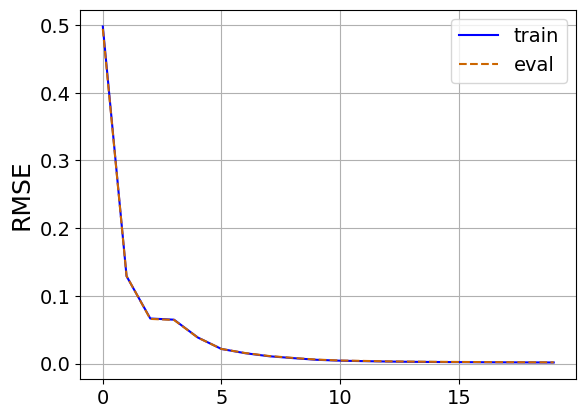

In [7]:
plt.plot(mod._train_loss, label="train")
plt.plot(mod._eval_loss, label="eval")
plt.legend();
plt.ylabel("RMSE");

In [8]:
y_hat = mod.predict(data[700_000:,3:].reshape((-1,1,5,5)))

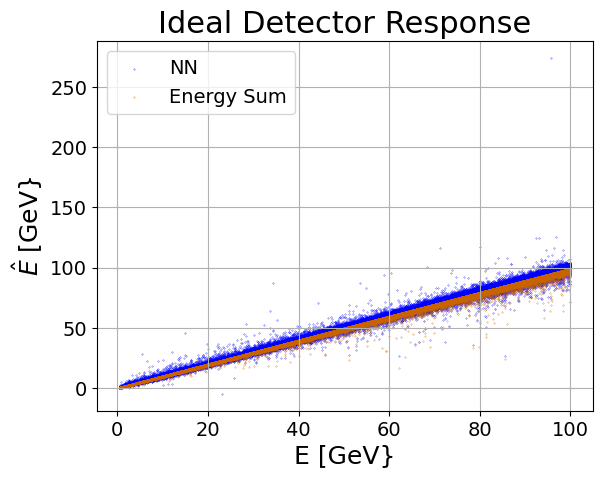

In [9]:
plt.scatter(data[700_000:,0]/1_000, y_hat/1_000, s=0.05, label="NN")
plt.scatter(data[700_000:,0]/1_000, data[700_000:,3:].sum(axis=1)/1_000, s=0.05, label="Energy Sum")
plt.legend();
plt.xlabel("E [GeV}");
plt.ylabel(r"$\hat{E}$ [GeV}");
plt.title("Ideal Detector Response");

In [10]:
nn_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": y_hat/1000}))
s_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": data[700_000:,3:].sum(axis=1)/1000}))

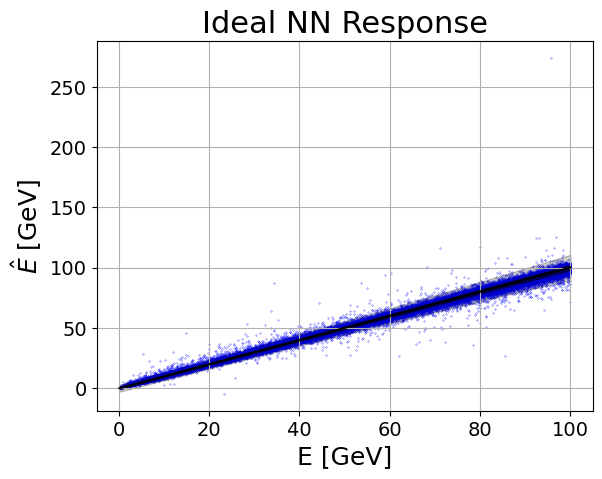

In [11]:
plt.scatter(data[700_000:,0]/1_000, y_hat/1_000, s=0.05, label="NN")
plot_continuous_response_model(nn_gam, np.linspace(0.1,100,100))
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");
plt.title("Ideal NN Response");

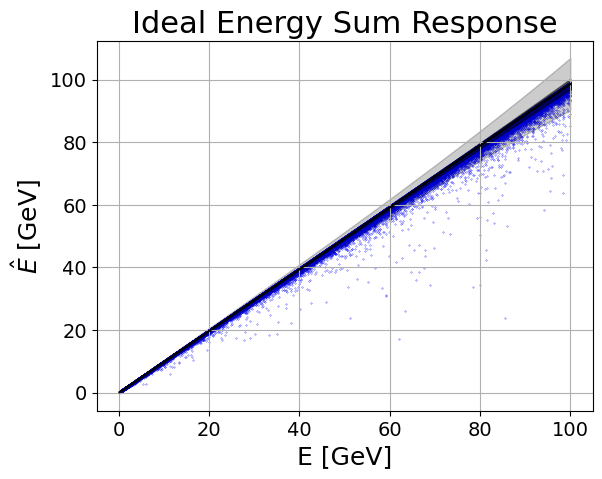

In [12]:
plt.scatter(data[700_000:,0]/1_000, data[700_000:,3:].sum(axis=1)/1_000, s=0.05, label="Energy Sum")
plot_continuous_response_model(s_gam, np.linspace(0.1,100,100))
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");
plt.title("Ideal Energy Sum Response");

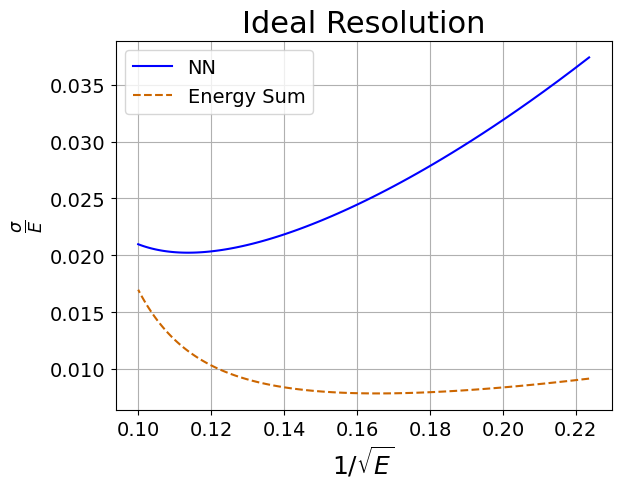

In [13]:
plot_continuous_resolution(nn_gam, np.linspace(20,100,100), label="NN")
plot_continuous_resolution(s_gam, np.linspace(20,100,100), label="Energy Sum")
plt.legend();
plt.xlabel(r"$1/\sqrt{E}$");
plt.ylabel(r"$\frac{\sigma}{E}$");
plt.title("Ideal Resolution");

It seems apparant from the response plots above that we have poorly estimated the shape of the distribution.  We have not investigated whether we can attribute the poor fit to the assumed normal distribution or the specification of the variance.  As we add noise contributions, the odd behavior seen in the resolution plot directly above will become moot as the comparisons have much less resolution.

Further study may bear fruit to understanding broader "thermodynamic" properties of calorimeters.

In [14]:
# save the model
torch.save(mod, "ereco_model.pt")

# Miscalibartion and Test Beam data
This section applies the miscalibration to the training dataset as well as data corresponding to three test beam points.  We compare the continuous and test beam resolution before and after miscalibration.

A random bias factor sampled from the uniform distribution on the interval $[0.05,0.1]$ get applied to each of the 25 readout channels.  This simulates, crudely, the response of photodetectors.  It is meant to be in the rough ballpark to convert the absorbed energy, which is proportional to the number of emitted scintillation photons, to something like an ADC count or other electronic measure.  The sampled bias factor is a constant and applied for all events.  In addition to scaling the output, we sample an additive noise term from a normal distribution.  The noise has a mean of zero and a variance $\sqrt{b_i}\sigma_i$ where $b_i$ is the channel bias factor and $\sigma_i$ is the variance of the simulated data in the channel.

In [15]:
# load the model
mod = torch.load("ereco_model.pt", weights_only=False)

In [16]:
mod._y_scale

(np.float32(50245.223), np.float32(28734.084))

In [17]:
mod._x_scale

(array([[[2.2079319e-02, 1.2949176e-01, 2.6034445e-01, 1.2927410e-01,
          2.1410320e-02],
         [1.3096280e-01, 2.5917332e+00, 2.7589039e+01, 2.5787139e+00,
          1.2938857e-01],
         [2.6399544e-01, 2.7612549e+01, 4.9357172e+04, 2.7592848e+01,
          2.5921240e-01],
         [1.2776160e-01, 2.5867260e+00, 2.7602196e+01, 2.5795672e+00,
          1.2853874e-01],
         [2.2939971e-02, 1.3014977e-01, 2.6094314e-01, 1.2738916e-01,
          2.1160325e-02]]], dtype=float32),
 array([[[8.1819075e-01, 1.7450371e+00, 1.8437803e+00, 1.3131121e+00,
          6.8253762e-01],
         [1.5197635e+00, 5.3874550e+00, 2.4391201e+01, 5.2479067e+00,
          1.3874334e+00],
         [2.2817471e+00, 2.4492746e+01, 2.8169174e+04, 2.4471355e+01,
          1.8390013e+00],
         [1.2305967e+00, 5.3808098e+00, 2.4454575e+01, 5.2986922e+00,
          1.2666714e+00],
         [7.7944666e-01, 1.5375656e+00, 1.9159585e+00, 1.2919537e+00,
          6.3225645e-01]]], dtype=float32))

In [18]:
# generate miscalibration and noise
bias_factor = np.random.uniform(0.05,0.1,25)

In [19]:
noise_var_gen = [sp.stats.norm(0, np.sqrt(bias_factor[i]*mod._x_scale[0].ravel()[i])) for i in range(25)]

In [20]:
data_noise = np.zeros(data[:,3:].shape)
for i in range(25):
    data_noise[:,i] = noise_var_gen[i].rvs(size=data_noise.shape[0])

In [21]:
data_miscalib = data[:,3:]*bias_factor + data_noise

In [22]:
data_miscalib.mean(axis=0)

array([1.94854823e-03, 9.24014067e-03, 2.49768644e-02, 6.66086908e-03,
       1.34925837e-03, 1.12781317e-02, 2.26670393e-01, 1.60076475e+00,
       1.95283057e-01, 1.19999379e-02, 1.95260200e-02, 1.95552354e+00,
       2.86748494e+03, 1.42199923e+00, 1.35121920e-02, 1.22427393e-02,
       1.53921074e-01, 2.54585697e+00, 2.47547352e-01, 9.35289446e-03,
       1.83407552e-03, 9.24100841e-03, 2.15628086e-02, 1.15299030e-02,
       2.04613177e-03])

In [23]:
data.mean(axis=0)

array([ 5.0241344e+04,  1.0583847e-02, -4.5449925e-03,  2.2079319e-02,
        1.2949176e-01,  2.6034445e-01,  1.2927410e-01,  2.1410320e-02,
        1.3096280e-01,  2.5917332e+00,  2.7589039e+01,  2.5787139e+00,
        1.2938857e-01,  2.6399544e-01,  2.7612549e+01,  4.9357172e+04,
        2.7592848e+01,  2.5921240e-01,  1.2776160e-01,  2.5867260e+00,
        2.7602196e+01,  2.5795672e+00,  1.2853874e-01,  2.2939971e-02,
        1.3014977e-01,  2.6094314e-01,  1.2738916e-01,  2.1160325e-02],
      dtype=float32)

In [24]:
y_hat_miscalib = mod.predict(data_miscalib[700_000:,:].reshape((-1,1,5,5)))

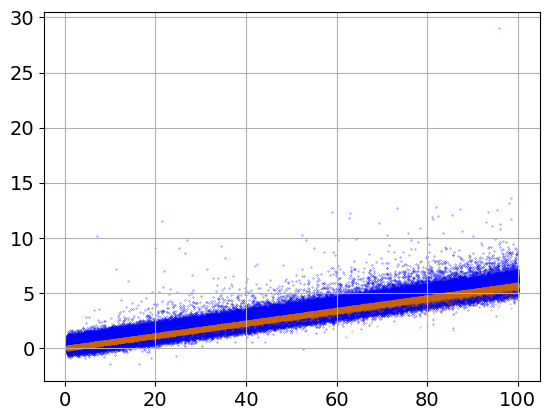

In [25]:
plt.scatter(data[700_000:,0]/1_000, y_hat_miscalib/1_000, s=0.05)
plt.scatter(data[700_000:,0]/1_000, data_miscalib[700_000:,:].sum(axis=1)/1_000, s=0.05)

In [26]:
nn_miscalib_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": y_hat_miscalib/1000}))
s_miscalib_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": data_miscalib[700_000:,:].sum(axis=1)/1000}))

In [27]:
print(ro.r.summary(s_miscalib_gam))


Family: gaulss 
Link function: identity logb 

Formula:
y ~ 0 + x
~1 + x

Parametric coefficients:
                Estimate Std. Error z value Pr(>|z|)    
x              5.722e-02  2.214e-06 25845.0   <2e-16 ***
(Intercept).1 -3.216e+00  3.143e-03 -1023.2   <2e-16 ***
x.1            5.507e-03  5.301e-05   103.9   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Deviance explained = 99.9%
-REML = -4.0364e+05  Scale est. = 1         n = 300000



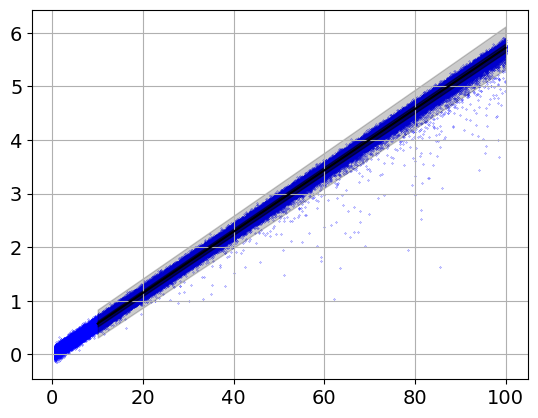

In [28]:
plt.scatter(data[700_000:,0]/1_000, data_miscalib[700_000:,:].sum(axis=1)/1_000, s=0.05)
plot_continuous_response_model(s_miscalib_gam, np.linspace(10,100,100))

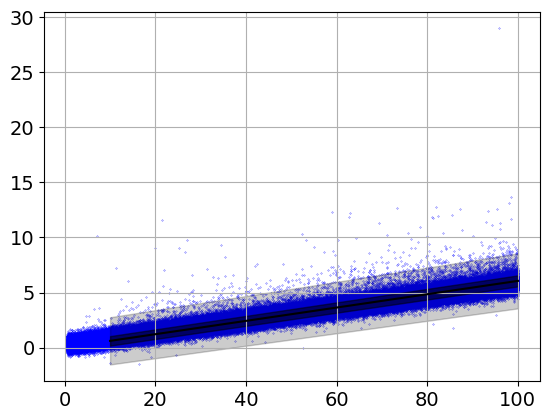

In [29]:
plt.scatter(data[700_000:,0]/1_000, y_hat_miscalib/1000, s=0.05)
plot_continuous_response_model(nn_miscalib_gam, np.linspace(10,100,100))

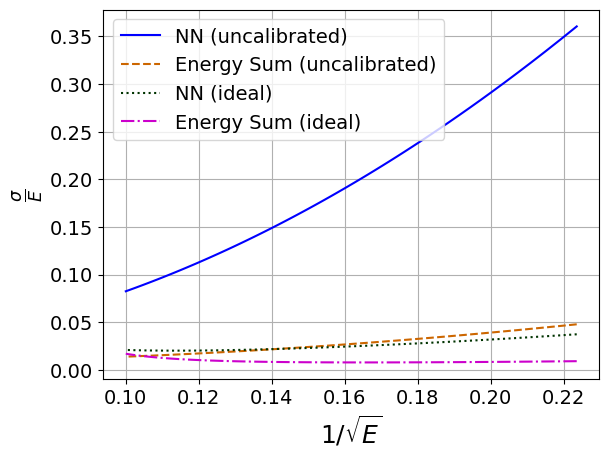

In [30]:
plot_continuous_resolution(nn_miscalib_gam, np.linspace(20,100,100), label="NN (uncalibrated)")
plot_continuous_resolution(s_miscalib_gam, np.linspace(20,100,100), label="Energy Sum (uncalibrated)")
plot_continuous_resolution(nn_gam, np.linspace(20,100,100), label="NN (ideal)")
plot_continuous_resolution(s_gam, np.linspace(20,100,100), label="Energy Sum (ideal)")
plt.legend()
plt.xlabel(r"$1/\sqrt{E}$");
plt.ylabel(r"$\frac{\sigma}{E}$");

The plot above shows the continuous resolution estiamted by the GAM method described above for the ideal and uncalibrated neural network and energy sum responeses.  We can easily see the NN's sensitivity to noise. 

In [31]:
# load calibration data
X20 = np.load("../python/simple-ecal-20GeV-test.npy")
X30 = np.load("../python/simple-ecal-30GeV-test.npy")
X50 = np.load("../python/simple-ecal-50GeV-test.npy")

In [32]:
X20[:,3:] = X20[:,3:]*bias_factor + np.array([noise_var_gen[i].rvs(size=X20.shape[0]) for i in range(25)]).T

In [33]:
X30[:,3:] = X30[:,3:]*bias_factor + np.array([noise_var_gen[i].rvs(size=X30.shape[0]) for i in range(25)]).T

In [34]:
X50[:,3:] = X50[:,3:]*bias_factor + np.array([noise_var_gen[i].rvs(size=X50.shape[0]) for i in range(25)]).T

In [35]:
y_hat_20 = (mod.predict(X20[:,3:].reshape((-1,1,5,5))))/1000

In [36]:
y_hat_30 = (mod.predict(X30[:,3:].reshape((-1,1,5,5))))/1000

In [37]:
y_hat_50 = (mod.predict(X50[:,3:].reshape((-1,1,5,5))))/1000

In [38]:
s_hat_20 = np.sum(X20[:,3:], axis=1)/1000
s_hat_30 = np.sum(X30[:,3:], axis=1)/1000
s_hat_50 = np.sum(X50[:,3:], axis=1)/1000

In [39]:
y_hat_means = np.array([np.mean(y_hat_20), np.mean(y_hat_30), np.mean(y_hat_50)])
y_hat_stds = np.array([np.std(y_hat_20), np.std(y_hat_30), np.std(y_hat_50)])
s_hat_means = np.array([np.mean(s_hat_20), np.mean(s_hat_30), np.mean(s_hat_50)])
s_hat_stds =  np.array([np.std(s_hat_20), np.std(s_hat_30), np.std(s_hat_50)])

In [40]:
test_points = np.array([20, 30, 50])

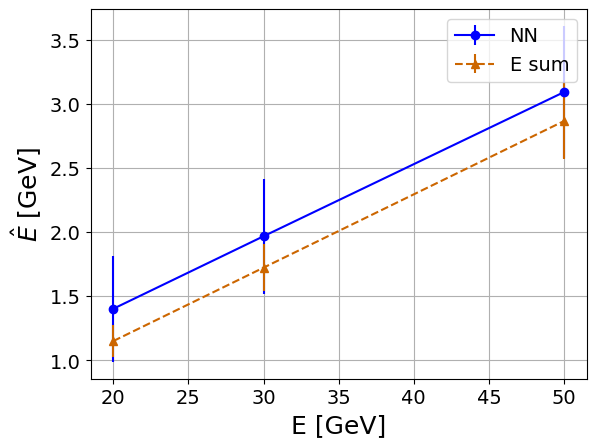

In [41]:
plt.errorbar(test_points, y_hat_means, y_hat_stds, marker="o", label="NN")
plt.errorbar(test_points, s_hat_means, s_hat_stds, marker="^", label="E sum")
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");
plt.legend();

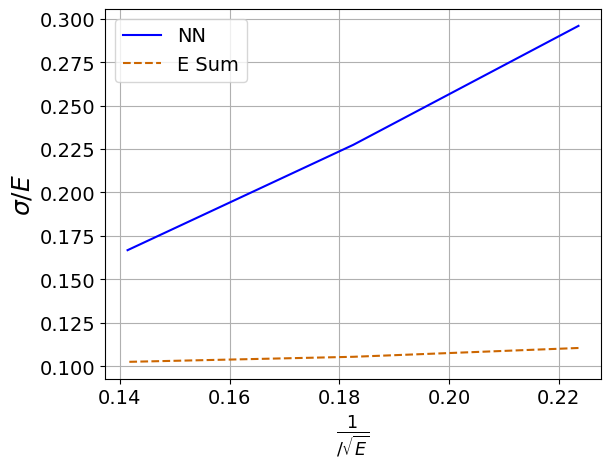

In [42]:
plt.plot(1./np.sqrt(test_points), y_hat_stds/y_hat_means, label="NN")
plt.plot(1./np.sqrt(test_points), s_hat_stds/s_hat_means, label="E Sum")
plt.xlabel(r"$\frac{1}{/\sqrt{E}}$");
plt.ylabel(r"$\sigma/E$");
plt.legend();

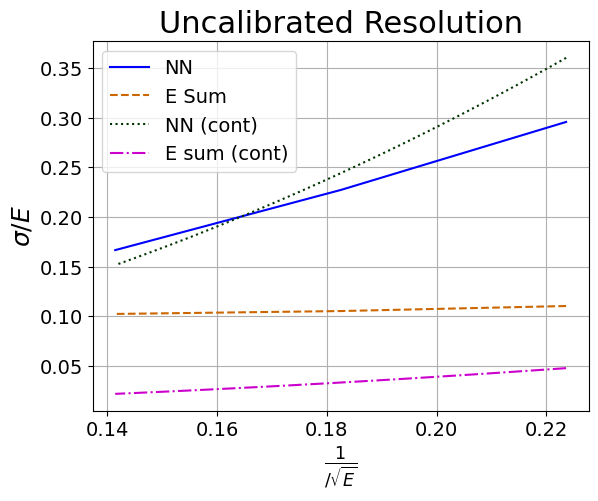

In [43]:
plt.plot(1./np.sqrt(test_points), y_hat_stds/y_hat_means, label="NN")
plt.plot(1./np.sqrt(test_points), s_hat_stds/s_hat_means, label="E Sum")
plot_continuous_resolution(nn_miscalib_gam, np.linspace(20,50,100), label="NN (cont)")
plot_continuous_resolution(s_miscalib_gam, np.linspace(20,50,100), label="E sum (cont)")
plt.xlabel(r"$\frac{1}{/\sqrt{E}}$");
plt.ylabel(r"$\sigma/E$");
plt.legend();
plt.title("Uncalibrated Resolution");

The plot above compares the uncalibrated resolution estimated continuously with GAMs or from a test beam analogous scenario at discrete (noisy) beam energies.  It is a bit surprising seeing the continuously estimated NN resulotion is worse than when estimated at discrete energy points.  The perseved resolution degration shown between the two energy sum curves comports with our initial expectation. 

# Calibration 1: Post-reco Calibration
Our first calibration technique to explore simply identifies a linear relationship between the reconstructed energy and the true energy (test beam).  As one can see above, both the NN and energy sum maintain linear responses in the presence of miscalibration.  This method as an advantageous simplicity, but the lack of correcting individual crystal responses remains a disadvantage.

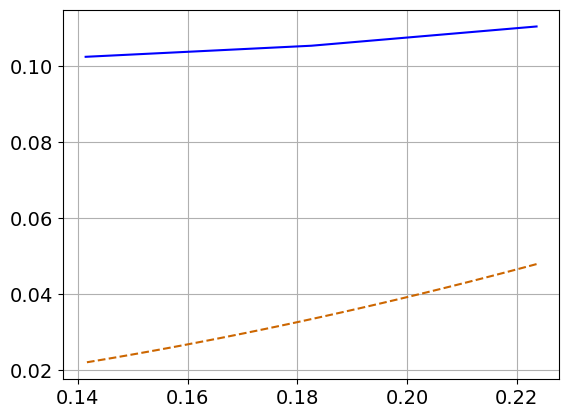

In [44]:
plt.plot(1./np.sqrt(test_points), s_hat_stds/s_hat_means)
plot_continuous_resolution(s_miscalib_gam, np.linspace(20,50,100))

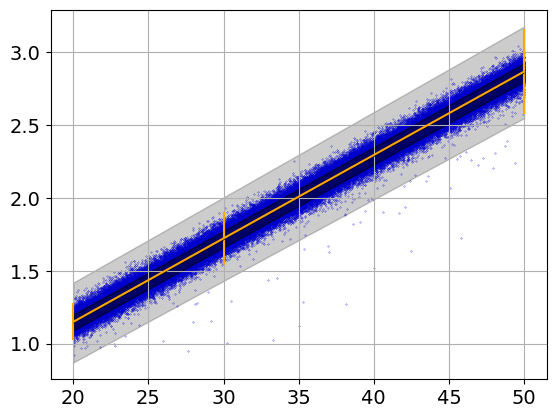

In [45]:
indx = (data[700_000:,0] >= 20_000) & (data[700_000:,0] <= 50_000)
plt.scatter(data[700_000:,0][indx]/1000, data_miscalib[700_000:,3:].sum(axis=1)[indx]/1000, s=0.05)
plt.errorbar(test_points, s_hat_means, s_hat_stds, color='orange')
plot_continuous_response_model(s_miscalib_gam, np.linspace(20,50,100))

In [46]:
nn_post_reco_mod = sm.GLM(test_points, sm.add_constant(y_hat_means)).fit()
nn_post_reco_mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                    3
Model:                            GLM   Df Residuals:                        1
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                       0.0011162
Method:                          IRLS   Log-Likelihood:                 7.5879
Date:                Mon, 29 Sep 2025   Deviance:                    0.0011162
Time:                        19:34:23   Pearson chi2:                  0.00112
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.8853      0.062    -78.573      0.000      -5.007      -4.763
x1            17.7474      0.027    646.597      0.000      17.694      17.801
==============================================================================
"""

In [47]:
sum_post_reco_mod = sm.GLM(test_points, sm.add_constant(s_hat_means)).fit()
sum_post_reco_mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                    3
Model:                            GLM   Df Residuals:                        1
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                      5.2075e-05
Method:                          IRLS   Log-Likelihood:                 12.185
Date:                Mon, 29 Sep 2025   Deviance:                   5.2075e-05
Time:                        19:34:23   Pearson chi2:                 5.21e-05
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0839      0.012     -7.042      0.000      -0.107      -0.061
x1            17.4728      0.006   2993.562      0.000      17.461      17.484
==============================================================================
"""

In [48]:
y_hat_post_reco = [
    nn_post_reco_mod.predict(sm.add_constant(y_hat_20)),
    nn_post_reco_mod.predict(sm.add_constant(y_hat_30)),
    nn_post_reco_mod.predict(sm.add_constant(y_hat_50))
]

In [49]:
y_hat_post_reco_means = np.array([preds.mean() for preds in y_hat_post_reco])
y_hat_post_reco_stds = np.array([preds.std() for preds in y_hat_post_reco])

In [50]:
s_hat_post_reco = [
    sum_post_reco_mod.predict(sm.add_constant(s_hat_20)),
    sum_post_reco_mod.predict(sm.add_constant(s_hat_30)),
    sum_post_reco_mod.predict(sm.add_constant(s_hat_50))
]

In [51]:
s_hat_post_reco_means = np.array([preds.mean() for preds in s_hat_post_reco])
s_hat_post_reco_stds = np.array([preds.std() for preds in s_hat_post_reco])

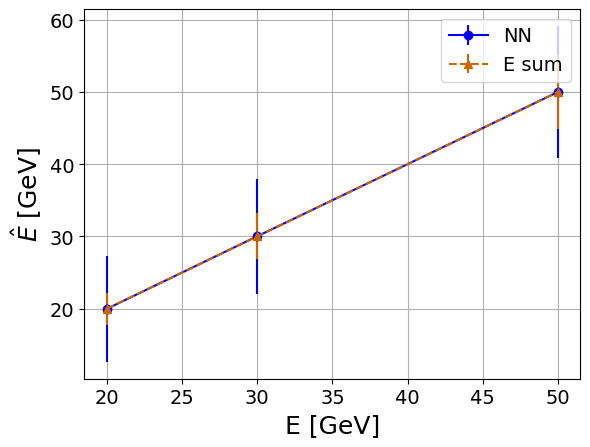

In [52]:
plt.errorbar(test_points, y_hat_post_reco_means, y_hat_post_reco_stds, marker="o", label="NN")
plt.errorbar(test_points, s_hat_post_reco_means, s_hat_post_reco_stds, marker="^", label="E sum")
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");
plt.legend();

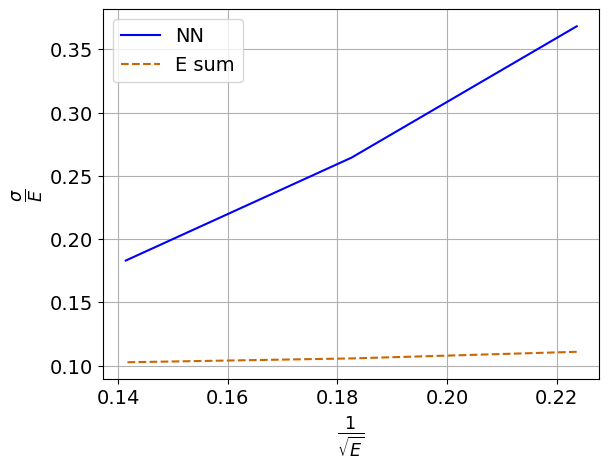

In [53]:
plt.plot(1./np.sqrt(test_points), y_hat_post_reco_stds/y_hat_post_reco_means, label="NN");
plt.plot(1./np.sqrt(test_points), s_hat_post_reco_stds/s_hat_post_reco_means, label="E sum");
plt.xlabel(r"$\frac{1}{\sqrt{E}}$");
plt.ylabel(r"$\frac{\sigma}{E}$");
plt.legend();

In [54]:
# calibrate data 
y_hat_post_reco_cont = nn_post_reco_mod.predict(sm.add_constant(y_hat_miscalib/1000))
s_hat_post_reco_cont = sum_post_reco_mod.predict(sm.add_constant(data_miscalib[700_000:,:].sum(axis=1)/1000))

In [55]:
nn_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": y_hat_post_reco_cont}))

In [56]:
s_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": s_hat_post_reco_cont}))

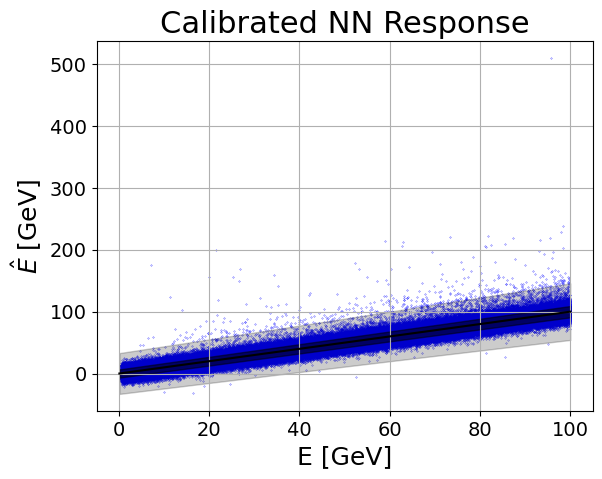

In [57]:
plt.scatter(data[700_000:,0]/1000, y_hat_post_reco_cont, s=0.05)

plot_continuous_response_model(nn_gam, np.linspace(0.1, 100,100))

plt.ylabel(r"$\hat{E}$ [GeV]");
plt.xlabel("E [GeV]");
plt.title("Calibrated NN Response");

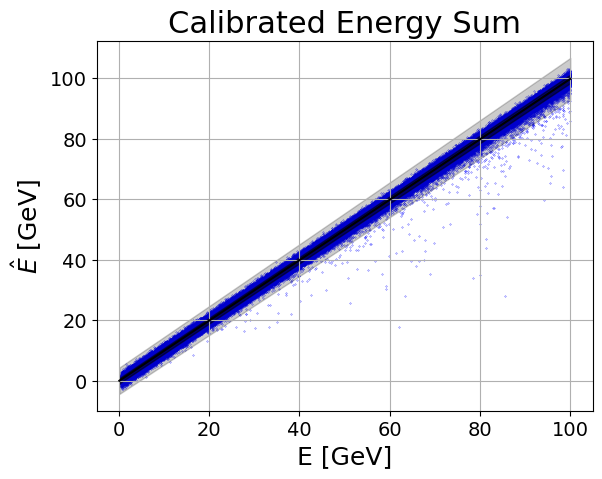

In [58]:
plt.scatter(data[700_000:,0]/1000, s_hat_post_reco_cont, s=0.05)

plot_continuous_response_model(s_gam, np.linspace(0.1,100, 100))

plt.ylabel(r"$\hat{E}$ [GeV]");
plt.xlabel("E [GeV]");
plt.title("Calibrated Energy Sum");

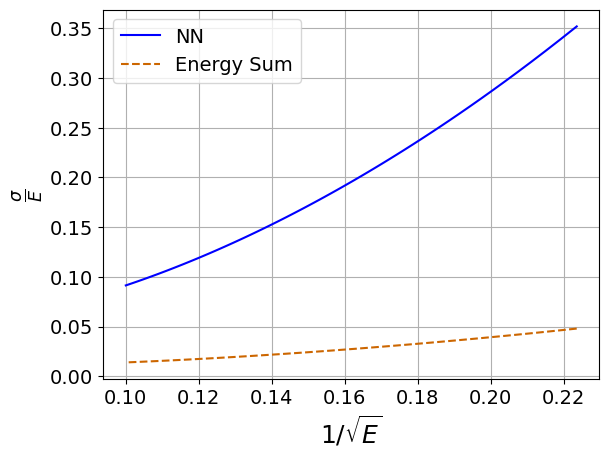

In [59]:
plot_continuous_resolution(nn_gam, np.linspace(20, 100, 100), label="NN")
plot_continuous_resolution(s_gam, np.linspace(20, 100, 100), label="Energy Sum")
plt.xlabel(r"$1/\sqrt{E}$");
plt.ylabel(r"$\frac{\sigma}{E}$");
plt.legend();

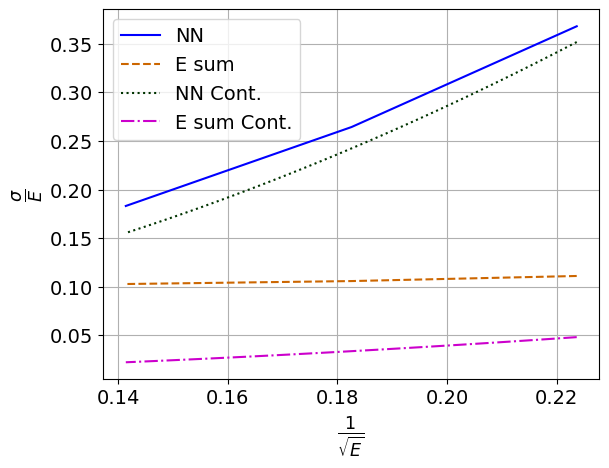

In [60]:
plt.plot(1./np.sqrt(test_points), y_hat_post_reco_stds/y_hat_post_reco_means, label="NN");
plt.plot(1./np.sqrt(test_points), s_hat_post_reco_stds/s_hat_post_reco_means, label="E sum");
plot_continuous_resolution(nn_gam, np.linspace(20,50,100), label="NN Cont.");
plot_continuous_resolution(s_gam, np.linspace(20,50,100),label="E sum Cont.");
plt.xlabel(r"$\frac{1}{\sqrt{E}}$");
plt.ylabel(r"$\frac{\sigma}{E}$");
plt.legend();

The response plots above show that by simply applying a linear calibration to the naively estimated energy recovers to a good degree the anticipated energy.  The calibration makes little to no effect on the energy sum resolution irrespective of resultion estimation methodology.  However, we do note a degradation of the NN's TB resolution.  There is a corresponding improvement to the continuous resolution estimate of the NN response such that after calibration, the order of the two estimation techniques comports with our expectations.

*Why is this?  How is a linear transform altering the distribution?*

In [61]:
np.sqrt(np.mean((data[700_000:,0]-y_hat_post_reco_cont)**2))/1000

np.float64(57.814415976715466)

In [62]:
np.sqrt(np.mean((data[700_000:,0]-s_hat_post_reco_cont)**2))/1000

np.float64(57.81448478521504)

# Calibration 2: Pre-Reco Calibration
This method attempts to recover the calibration constants for each crystal through a linear regression.

In [63]:
# load additional test beam training data
X20_train = np.load("../python/simple-ecal-20GeV-train.npy")
X30_train = np.load("../python/simple-ecal-30GeV-train.npy")
X50_train = np.load("../python/simple-ecal-50GeV-train.npy")

X20_train[:,3:] = X20_train[:,3:]*bias_factor + np.array([noise_var_gen[i].rvs(size=X20_train.shape[0]) for i in range(25)]).T
X30_train[:,3:] = X30_train[:,3:]*bias_factor + np.array([noise_var_gen[i].rvs(size=X30_train.shape[0]) for i in range(25)]).T
X50_train[:,3:] = X50_train[:,3:]*bias_factor + np.array([noise_var_gen[i].rvs(size=X50_train.shape[0]) for i in range(25)]).T

In [64]:
X_test = np.concatenate((X20[:,3:], X30[:,3:], X50[:,3:]))
X_train = np.concatenate((X20_train[:,3:], X30_train[:,3:], X50_train[:,3:]))

In [65]:
y_test = np.concatenate(([20]*X20.shape[0], [30]*X30.shape[0], [50]*X50.shape[0]))*1000
y_train = np.concatenate(([20]*X20_train.shape[0], [30]*X30_train.shape[0], [50]*X50_train.shape[0]))*1000

In [66]:
calib_mod = sm.GLM(y_train, X_train).fit()

In [67]:
calib_mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:               150000
Model:                            GLM   Df Residuals:                   149999
Model Family:                Gaussian   Df Model:                            0
Link Function:               Identity   Scale:                      1.3301e+07
Method:                          IRLS   Log-Likelihood:            -1.4431e+06
Date:                Mon, 29 Sep 2025   Deviance:                   1.9951e+12
Time:                        19:34:29   Pearson chi2:                 2.00e+12
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1           160.6257    148.743      1.080      0.280    -130.905     452.156
x2            11.7686     80.242      0.147      0.883    -145.502     169.039
x3            61.3390     38.093      1.610      0.107     -13.322     136.000
x4            78.4168    101.653      0.771      0.440    -120.820     277.654
x5          -190.1160    206.216     -0.922      0.357    -594.292     214.060
x6           199.5930     72.592      2.750      0.006      57.314     341.872
x7            26.1008     16.003      1.631      0.103      -5.264      57.465
x8            26.6063      6.355      4.187      0.000      14.151      39.062
x9            55.4100     17.159      3.229      0.001      21.779      89.041
x10           36.4912     61.706      0.591      0.554     -84.450     157.433
x11           43.7339     46.685      0.937      0.349     -47.767     135.235
x12           37.1281      5.553      6.686      0.000      26.244      48.012
x13           17.2266      0.009   1920.665      0.000      17.209      17.244
x14           18.6901      6.829      2.737      0.006       5.305      32.075
x15           46.5104     63.993      0.727      0.467     -78.914     171.935
x16           52.3037     59.487      0.879      0.379     -64.290     168.897
x17           44.5869     20.600      2.164      0.030       4.211      84.963
x18           28.3331      4.648      6.095      0.000      19.222      37.444
x19           49.2726     13.806      3.569      0.000      22.214      76.331
x20           36.8185     62.132      0.593      0.553     -84.959     158.596
x21          220.8831    147.718      1.495      0.135     -68.638     510.405
x22           14.2869     76.006      0.188      0.851    -134.682     163.256
x23          139.7342     50.455      2.769      0.006      40.844     238.624
x24           79.7594     66.491      1.200      0.230     -50.561     210.080
x25           25.7571    125.668      0.205      0.838    -220.548     272.062
==============================================================================
"""

In [68]:
1./bias_factor

array([11.64327625, 14.04853284, 10.38702796, 19.04570352, 15.96715113,
       11.69359281, 11.45856454, 17.2569864 , 13.20207608, 10.6716104 ,
       13.42004293, 14.11400275, 17.2118251 , 19.41867658, 18.99434704,
       10.25712757, 16.82999719, 10.8252676 , 10.4472538 , 13.58132634,
       12.40922877, 14.06713795, 12.01394064, 11.00548167, 10.69676202])

In [69]:
(calib_mod.params - 1./bias_factor)[[6,7,8,11,12,13,16,17,18]]

array([ 1.46422207e+01,  9.34929946e+00,  4.22079011e+01,  2.30140773e+01,
        1.47736353e-02, -7.28624585e-01,  2.77568975e+01,  1.75078122e+01,
        3.88253592e+01])

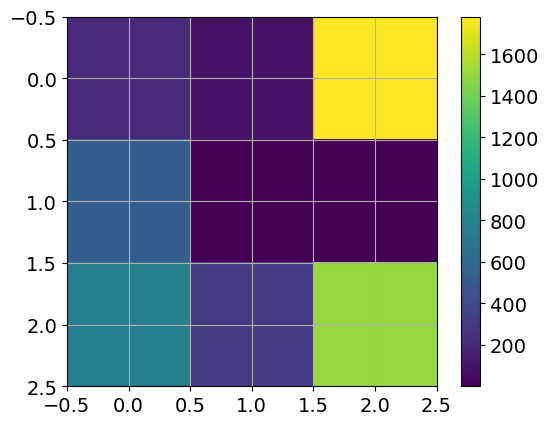

In [70]:
plt.imshow((calib_mod.params - 1./bias_factor)[[6,7,8,11,12,13,16,17,18]].reshape((3,3))**2)
plt.colorbar();

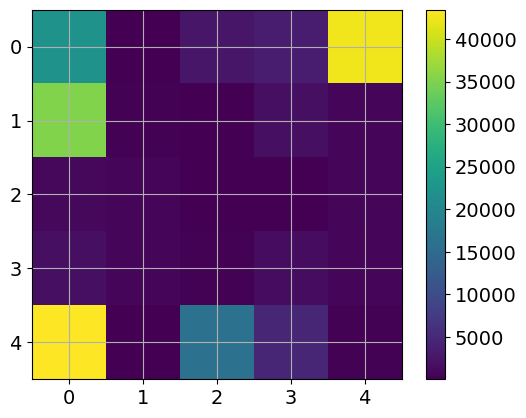

In [71]:
plt.imshow((calib_mod.params - 1./bias_factor).reshape((5,5))**2)
plt.colorbar();

In [72]:
X_valid_miscalib = data_miscalib[700_000:,:]

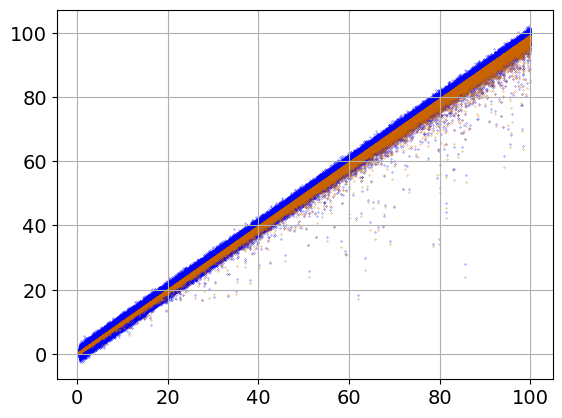

In [73]:
plt.scatter(data[700_000:,0]/1_000, calib_mod.predict(X_valid_miscalib)/1_000, s=0.05)
plt.scatter(data[700_000:,0]/1_000, data[700_000:,3:].sum(axis=1)/1_000, s=0.05)

In [74]:
(X_valid_miscalib*calib_mod.params).sum(axis=1)

array([20347.36125345, 49502.27919113, 36037.70371634, ...,
       16728.81201256, 45755.22197945, 89440.62388589], shape=(300000,))

In [75]:
y_hat_pre_calib = mod.predict((X_valid_miscalib*calib_mod.params).reshape((-1,1,5,5)))

In [76]:
y_hat_pre_test = np.array([mod.predict((X[:,3:]*calib_mod.params).reshape((-1,1,5,5))) for X in [X20, X30, X50]])
y_hat_pre_means = np.mean(y_hat_pre_test, axis=1)
y_hat_pre_stds = np.std(y_hat_pre_test, axis=1)

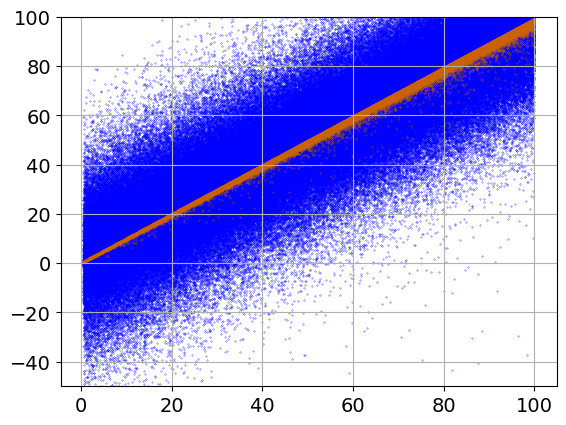

In [77]:
plt.scatter(data[700_000:,0]/1_000, y_hat_pre_calib/1_000, s=0.05)
plt.scatter(data[700_000:,0]/1_000, data[700_000:,3:].sum(axis=1)/1_000, s=0.05)
plt.ylim([-50,100]);

In [78]:
s_pre_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": calib_mod.predict(X_valid_miscalib)/1_000}))

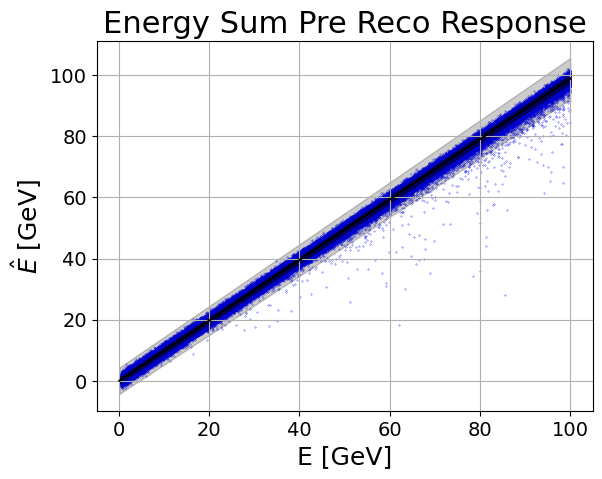

In [79]:
plt.scatter(data[700_000:,0]/1000, calib_mod.predict(X_valid_miscalib)/1000, s=0.05)
plot_continuous_response_model(s_pre_gam, np.linspace(0.1,100,100))
plt.xlabel(r"E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");
plt.title("Energy Sum Pre Reco Response");

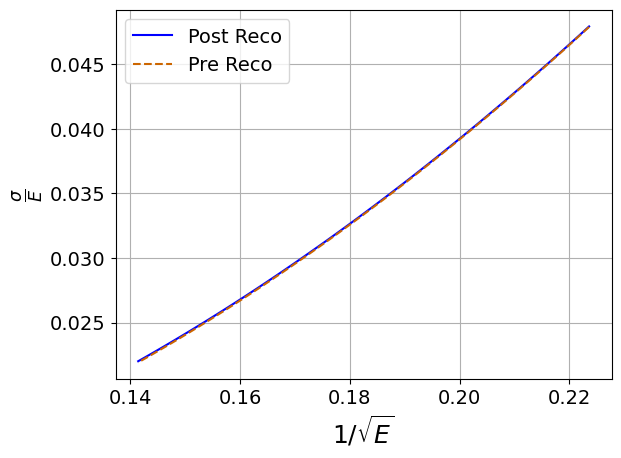

In [80]:
plot_continuous_resolution(s_gam, np.linspace(20,50,100), label="Post Reco");
plot_continuous_resolution(s_pre_gam, np.linspace(20,50,100), label="Pre Reco");
plt.legend();
plt.xlabel(r"$1/\sqrt{E}$");
plt.ylabel(r"$\frac{\sigma}{E}$");

The plot above compares the resolution, estimated continuously, for the energy sum calibrated pre- or post- reconstruction.  As expected, we see no difference in the estimated resolution.

In [81]:
nn_pre_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": y_hat_pre_calib/1000}))

In [82]:
print(ro.r.summary(nn_pre_gam))


Family: gaulss 
Link function: identity logb 

Formula:
y ~ 0 + x
~1 + x

Parametric coefficients:
               Estimate Std. Error  z value Pr(>|z|)    
x             9.935e-01  5.516e-04 1801.216   <2e-16 ***
(Intercept).1 2.852e+00  2.588e-03 1102.358   <2e-16 ***
x.1           9.098e-05  4.463e-05    2.039   0.0415 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Deviance explained = 71.1%
-REML = 1.283e+06  Scale est. = 1         n = 300000



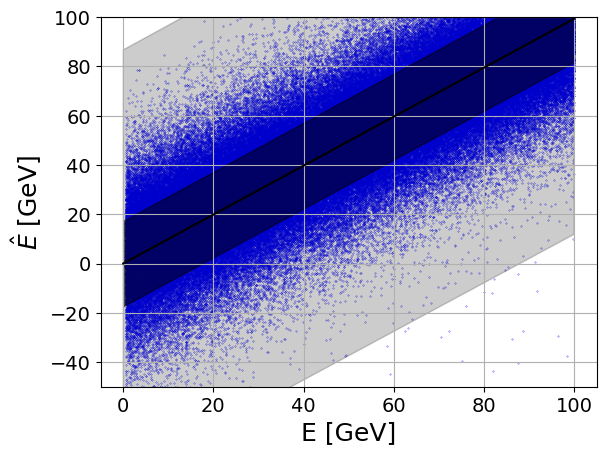

In [83]:
plt.scatter(data[700_000:,0]/1000, y_hat_pre_calib/1000, s=0.05)
plot_continuous_response_model(nn_pre_gam, np.linspace(0.01,100))
plt.ylim([-50,100]);
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");

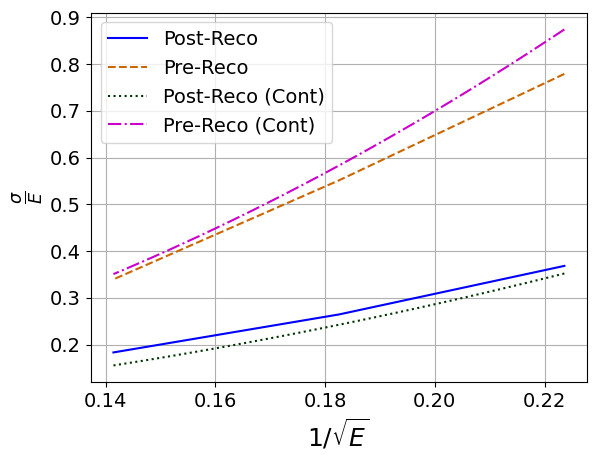

In [84]:
plt.plot(1./np.sqrt(test_points), y_hat_post_reco_stds/y_hat_post_reco_means, label="Post-Reco")
plt.plot(1./np.sqrt(test_points), y_hat_pre_stds/y_hat_pre_means, label="Pre-Reco")
plot_continuous_resolution(nn_gam, np.linspace(20,50,100), label="Post-Reco (Cont)")
plot_continuous_resolution(nn_pre_gam, np.linspace(20,50,100), label="Pre-Reco (Cont)")
plt.legend();
plt.xlabel(r"$1/\sqrt{E}$");
plt.ylabel(r"$\frac{\sigma}{E}$");

Comparing the pre-reconstruction to post-reconstruction calibration techniques for the NN reconstruction shows that attempting a linear correction to the input space further degrades the system's resolution.  The degration is large, and we see a similar degradation whether estimated in TB data or continuously.  Unlike the observed, negligible impact to the linear energy sum, the NN shows its sensitivity to the relationships among the input channels.

# Calibration 3: Rescale NN input/output
Another possibly simple method to calibrate the NN may be to simply re-estimate the means and variances used to standardize the input to reflect the miscalibrated distributions.  Since gradients tended to overflow when attempting to train the NN on the event energy scale, we have standardized the input and target distributions.  Under miscalibration, the input distributions have shifted significantly from the training distribution.  It would prove advantageous if we could achieve resonable calibration and resolution through a simple input correction.  We hold the standardization of the target consistent since there has been no change to the target distribution.  

In [85]:
miscalib_x_scale = (X_train.mean(axis=0).reshape((1,5,5)), X_train.std(axis=0).reshape((1,5,5)))

In [86]:
mod_rescale = torch.load("ereco_model.pt", weights_only=False)

In [87]:
mod_rescale._x_scale = copy.copy(miscalib_x_scale)

In [88]:
y_hat_rescale = (mod_rescale.predict(data_miscalib[700_000:,:].reshape((-1,1,5,5))))/1000

In [89]:
nn_rescale_gam = model_continuous_response(pd.DataFrame({"x": data[700_000:,0]/1000, "y": y_hat_rescale}))

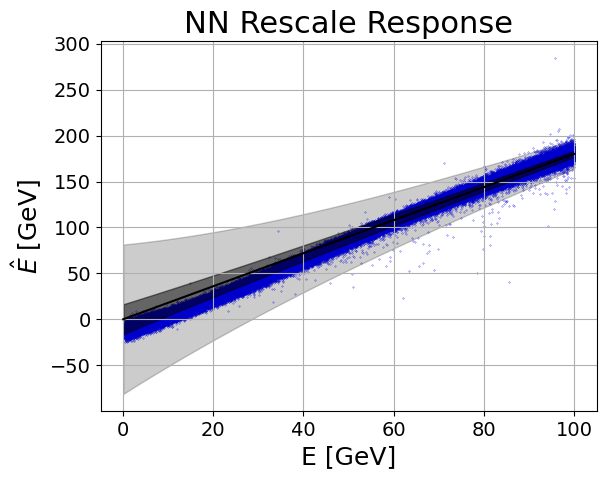

In [90]:
plt.scatter(data[700_000:,0]/1000, y_hat_rescale, s=0.05)

plot_continuous_response_model(nn_rescale_gam, np.linspace(0.1,100,100))

plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");
plt.title("NN Rescale Response");

In [91]:
y_hat_rescale_test = np.array([mod_rescale.predict(X[:,3:].reshape((-1,1,5,5))) for X in [X20, X30, X50]])
y_hat_rescale_means = np.mean(y_hat_rescale_test, axis=1)
y_hat_rescale_stds = np.std(y_hat_rescale_test, axis=1)

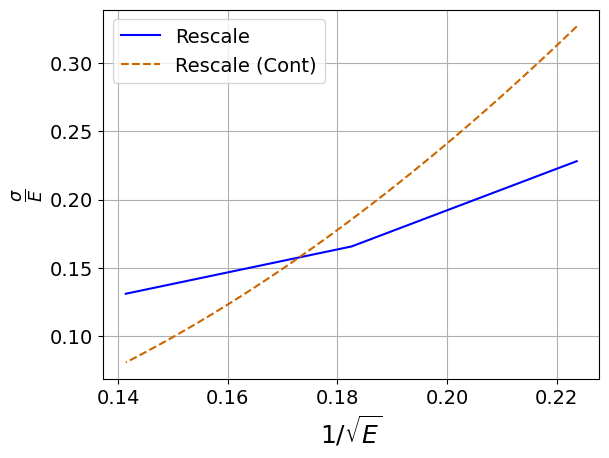

In [92]:
plt.plot(1./np.sqrt(test_points), y_hat_rescale_stds/y_hat_rescale_means, label="Rescale")
plot_continuous_resolution(nn_rescale_gam, np.linspace(20,50,100), label="Rescale (Cont)");
plt.legend()
plt.xlabel(r"$1/\sqrt{E}$");
plt.ylabel(r"$\frac{\sigma}{E}$");

# Calibration 4: Continue training NN
Alternatively, we could fine-tune the pre-fitted model with the miscalibrated data.  In this calibration scheme, we continue training - we continue updating the model weights - using the miscalibrated data.
We explore a few variants of this fine tuning option related to the input/output scaling applied.
1. Fine tune using original scaling on test beam data
2. Rescale data holding fine tune model 1 constant
3. Fine tune on miscalibrated continuous incident energy data

Options 1 and 2 resembe what could be possible in a real world situation where we have trained amodel on simulated data and need to calibrate the reconstruction based on test beam results.  The third option provides a comparison to benchmark miscalibration and fine tuning.  If one knew enough about the miscalibration process to simulate it effectively, one would not find themselves with the need to calibrate the model.

In [93]:
mod_ft = torch.load("ereco_model.pt", weights_only=False)
mod_ft.to("cuda")

Erecon(
  (conv1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1))
  (batch): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc0): Linear(in_features=25, out_features=256, bias=True)
  (fc1): Linear(in_features=256, out_features=144, bias=True)
  (fc2): Linear(in_features=144, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=1, bias=True)
  (_criterion): MSELoss()
  (_eval_criterion): MSELoss()
)

In [94]:
mod_ft.scalers(y_train, X_train.reshape((-1,1,5,5)))

In [95]:
mod_ft.fit(y_train, X_train.reshape((-1,1,5,5)), epochs=50)

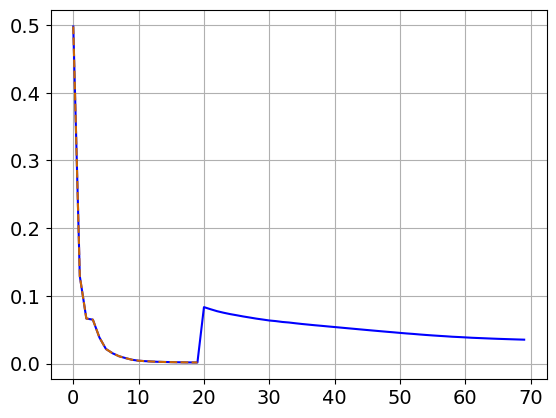

In [96]:
plt.plot(mod_ft._train_loss)
plt.plot(mod._train_loss)

In [97]:
y_hat_ft = mod_ft.predict(data_miscalib[700_000:,:].reshape((-1,1,5,5)))
y_hat_ft_test = np.array([mod_ft.predict(X[:,3:].reshape((-1,1,5,5))) for X in [X20, X30, X50]])
y_hat_ft_means = y_hat_ft_test.mean(axis=1)
y_hat_ft_stds = y_hat_ft_test.std(axis=1)

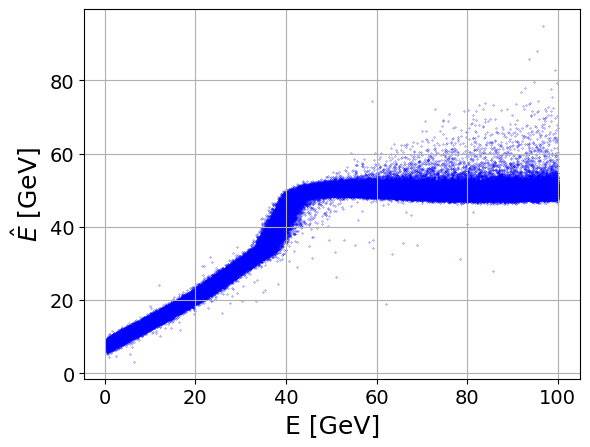

In [98]:
plt.scatter(data[700_000:,0]/1000, y_hat_ft/1000, s=0.05);
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");

In [100]:
# scale back to calibrated range
mod_ft._x_scale = copy.copy(mod._x_scale)
mod_ft._y_scale = copy.copy(mod._y_scale)

In [101]:
y_hat_ft_orig_scale = mod_ft.predict(data_miscalib[700_000:,:].reshape((-1,1,5,5)))
y_hat_ft_orig_scale_test = np.array([mod_ft.predict(X[:,3:].reshape((-1,1,5,5))) for X in [X20, X30, X50]])
y_hat_ft_orig_scale_means = y_hat_ft_test.mean(axis=1)
y_hat_ft_orig_scale_stds = y_hat_ft_test.std(axis=1)

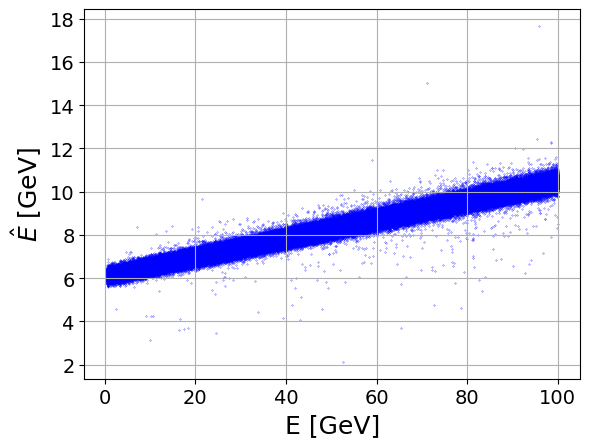

In [117]:
plt.scatter(data[700_000:,0]/1000, y_hat_ft_orig_scale/1000, s=0.05)
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");

In [119]:
mod_ft_2 = torch.load("ereco_model.pt", weights_only=False)
mod_ft_2.to("cuda")
mod_ft_2.fit(y_train, X_train.reshape((-1,1,5,5)), epochs=50)

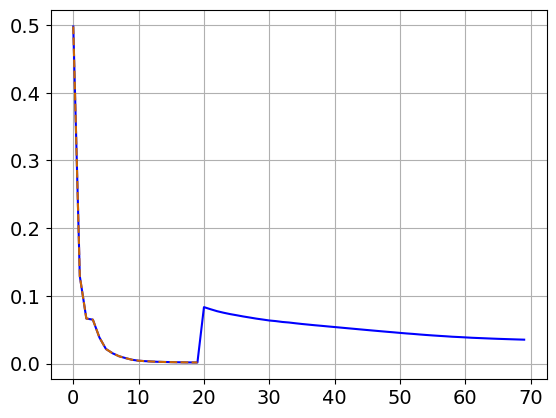

In [120]:
plt.plot(mod_ft._train_loss)
plt.plot(mod._train_loss)

In [121]:
y_hat_ft_2 = mod_ft_2.predict(data_miscalib[700_000:,:].reshape((-1,1,5,5)))
y_hat_ft_2_test = np.array([mod_ft_2.predict(X[:,3:].reshape((-1,1,5,5))) for X in [X20, X30, X50]])
y_hat_ft_2_means = y_hat_ft_2_test.mean(axis=1)
y_hat_ft_2_stds = y_hat_ft_2_test.std(axis=1)

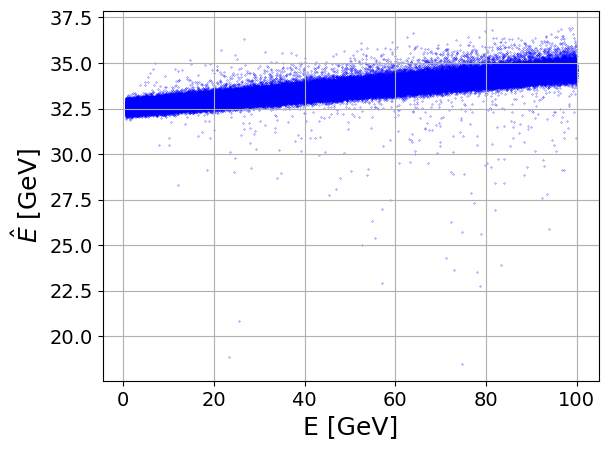

In [122]:
plt.scatter(data[700_000:,0]/1000, y_hat_ft_2/1000, s=0.05)
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");

In [125]:
mod_ft_3 = torch.load("ereco_model.pt", weights_only=False)
mod_ft_3.to("cuda")
mod_ft_3.fit(data[700_000:,0], data_miscalib[700_000:,:].reshape((-1,1,5,5)), epochs=50)

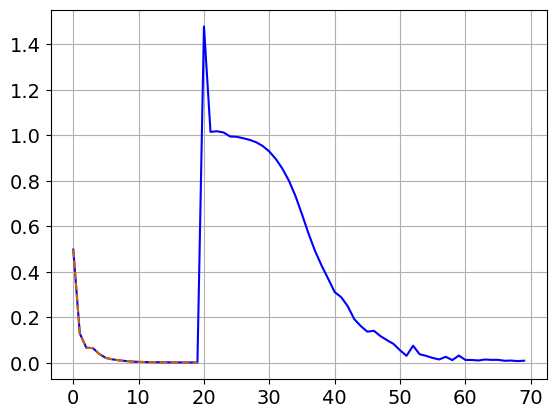

In [126]:
plt.plot(mod_ft_3._train_loss)
plt.plot(mod._train_loss)

In [127]:
y_hat_ft_3 = mod_ft_3.predict(data_miscalib[700_000:,:].reshape((-1,1,5,5)))
y_hat_ft_3_test = np.array([mod_ft_3.predict(X[:,3:].reshape((-1,1,5,5))) for X in [X20, X30, X50]])
y_hat_ft_3_means = y_hat_ft_3_test.mean(axis=1)
y_hat_ft_3_stds = y_hat_ft_3_test.std(axis=1)

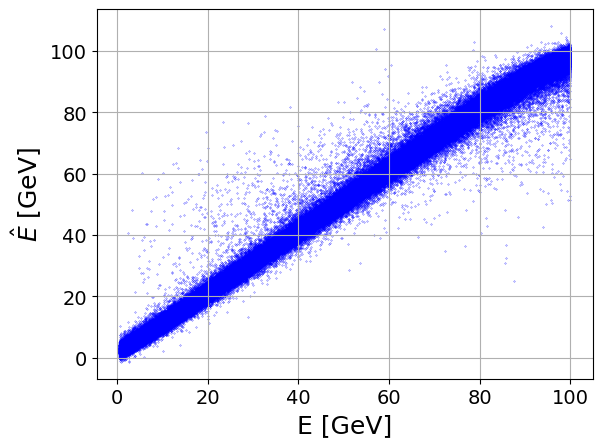

In [128]:
plt.scatter(data[700_000:,0]/1000, y_hat_ft_3/1000, s=0.05)
plt.xlabel("E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");

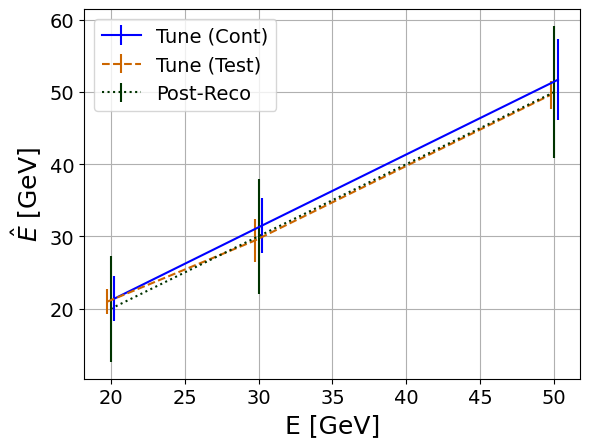

In [132]:
plt.errorbar(test_points+0.25, y_hat_ft_3_means/1000, y_hat_ft_3_stds/1000, label="Tune (Cont)");
plt.errorbar(test_points-0.25, y_hat_ft_means/1000, y_hat_ft_stds/1000, label="Tune (Test)");
plt.errorbar(test_points, y_hat_post_reco_means, y_hat_post_reco_stds, label="Post-Reco");
plt.legend()
plt.xlabel(r"E [GeV]");
plt.ylabel(r"$\hat{E}$ [GeV]");

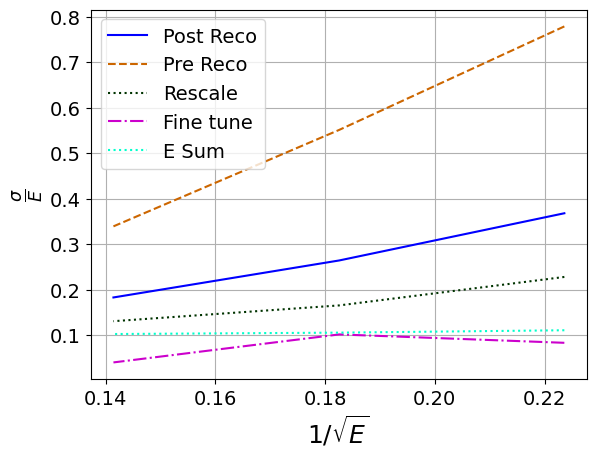

In [134]:
plt.plot(1./np.sqrt(test_points), y_hat_post_reco_stds/y_hat_post_reco_means, label="Post Reco");
plt.plot(1./np.sqrt(test_points), y_hat_pre_stds/y_hat_pre_means, label="Pre Reco");
plt.plot(1./np.sqrt(test_points), y_hat_rescale_stds/y_hat_rescale_means, label="Rescale");
plt.plot(1./np.sqrt(test_points), y_hat_ft_stds/y_hat_ft_means, label="Fine tune");
plt.plot(1./np.sqrt(test_points), s_hat_post_reco_stds/s_hat_post_reco_means, label="E Sum");
plt.legend();
plt.xlabel(r"$1/\sqrt{E}$");
plt.ylabel(r"$\frac{\sigma}{E}$");

Option 1 recovers the energy scale.  Unfortunately, it also introduces significant non-linearities in the response and a plateau in the response above the highest test beam point.  The resolution obtained within the test beam energy range exceeds the other calibration methods.  Option 2 does not recover the energy scale and requires.  Option 3 improves the resolution, not to the level of Option 1, and roughly maintains response linearity.  

# Train calibration NN layer

Finally, we consider adding a learnable calibration layer between the inputs and the first model layer.  This method resembles the linear pre-reco calibration technique attempted above.  This methods allows the calibration layer weights to be learned in context with the model prediction above.  We train the calibration layer with test beam data.

In [109]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from ereco import utils

In [110]:
class CalibrationLayerMod(nn.Module):
    def __init__(self, base_model_path="ereco_model.pt"):
        super().__init__()
        self.ereco_model = torch.load(base_model_path, weights_only=False)
        self.calibration_layer = nn.Linear(25,25)
        for param in self.ereco_model.parameters():
            param.requires_grad = False

        self._train_loss  = []
        self._eval_loss = []

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.calibration_layer(x)
        x = self.ereco_model(x)
        return x

    def fit(self, y, x, eval_set=None, batch_size=50_000, epochs=20):
        _criterion = nn.MSELoss()
        _eval_criterion = nn.MSELoss(reduction="sum")
        #optimizer = optim.SGD(self.parameters(), lr=0.001, momentum=0.9)
        _optimizer = optim.Adam(self.parameters(), lr=0.001)
        
        data = utils.EcalDataset(y, x, self.ereco_model._x_scale, self.ereco_model._y_scale)
        dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)

        if next(self.parameters()).is_cuda:
            self._to_cuda = True

        if eval_set:
            eval_set = DataLoader(
                        utils.EcalDataset(
                            eval_set[0],
                            eval_set[1],
                            self.ereco_model._x_scale,
                            self.ereco_model._y_scale
                        ),
                        batch_size=batch_size,
                        shuffle=True
                    )

        for ep in range(epochs):
            self._train_epoch(dataloader, _criterion, _optimizer)
            self._train_loss.append(self._eval_epoch(dataloader, _eval_criterion))
            if eval_set:
                self._eval_loss.append(self._eval_epoch(eval_set, _eval_criterion))
                
    def _train_epoch(self, dataloader, lf, optimizer):
        size = len(dataloader.dataset)
        self.train()
        for batch, (x, y) in enumerate(dataloader):
            if self._to_cuda:
                x = x.cuda()
                y = y.cuda()
            pred = self(x)
            loss = lf(pred, y)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    def _eval_epoch(self, dataloader, lf):
        self.eval()
        loss = 0.
        with torch.no_grad():
            for x, y in dataloader:
                if self._to_cuda:
                    x = x.cuda()
                    y = y.cuda()
                pred = self(x)
                loss += lf(pred, y).item()

        return loss/len(dataloader.dataset)

    def predict(self, x, batch_size=50_000):
        dataloader = DataLoader(
            utils.EcalDataset(
                np.zeros(x.shape[0]),
                x,
                self.ereco_model._x_scale,
                self.ereco_model._y_scale
            ),
            batch_size=batch_size,
            shuffle=False
        )

        if next(self.parameters()).is_cuda:
            self._to_cuda = True

        self.eval()
        with torch.no_grad():
            for batch, (x, y) in enumerate(dataloader):
                start = batch*batch_size
                end = (batch+1)*batch_size
                if self._to_cuda:
                    x = x.cuda()
                    y = y.cuda()
                dataloader.dataset.y[start:end] = self(x).cpu().flatten()

        return dataloader.dataset.scaleY()


In [111]:
cali_mod = CalibrationLayerMod()
cali_mod.to("cuda")

CalibrationLayerMod(
  (ereco_model): Erecon(
    (conv1): Conv2d(1, 16, kernel_size=(2, 2), stride=(1, 1))
    (batch): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc0): Linear(in_features=25, out_features=256, bias=True)
    (fc1): Linear(in_features=256, out_features=144, bias=True)
    (fc2): Linear(in_features=144, out_features=84, bias=True)
    (fc3): Linear(in_features=84, out_features=1, bias=True)
    (_criterion): MSELoss()
    (_eval_criterion): MSELoss()
  )
  (calibration_layer): Linear(in_features=25, out_features=25, bias=True)
)

In [112]:
cali_mod.fit(y_train, X_train.reshape((-1,1,5,5)), epochs=50)

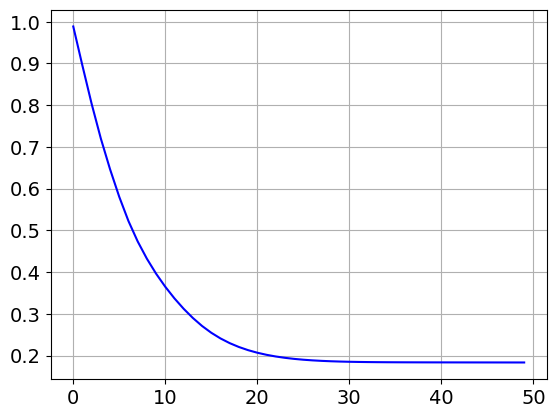

In [113]:
plt.plot(cali_mod._train_loss)

In [114]:
y_hat_calilayer_test = [cali_mod.predict(X.reshape((-1,1,5,5))) for X in [X20, X30, X50]]
y_hat_calilayer = cali_mod.predict(data_miscalib[700_000:,:].reshape((-1,1,5,5)))

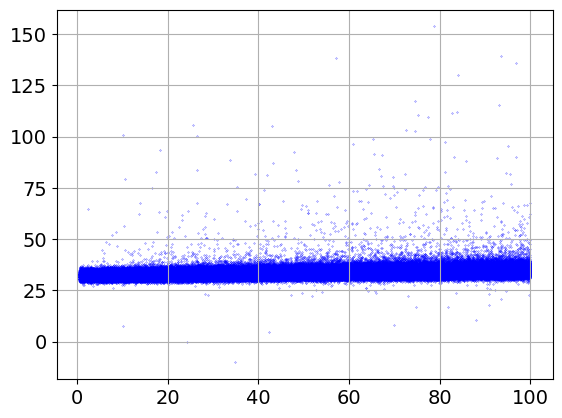

In [115]:
plt.scatter(data[700_000:,0]/1000, y_hat_calilayer/1000, s=0.05)

<ErrorbarContainer object of 3 artists>

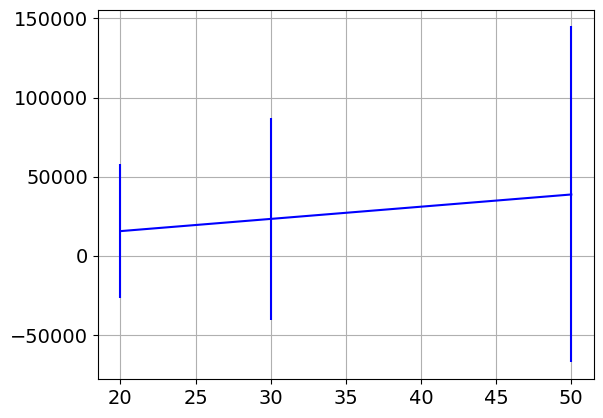

In [116]:
plt.errorbar([20, 30, 50], np.mean(y_hat_calilayer_test,axis=1)/1000, np.std(y_hat_calilayer_test, axis=1)/1000)